In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from get_ddf import get_hourly_df
from data_handling import *
import statsmodels.api as sm
from scipy.stats import gaussian_kde as kde
import sys 
from scipy.optimize import minimize
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']
coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {
    'kahiltna':['K17b','K53'], # KAHILTNA     'KPS','K14k',
    'kennicott':['GTH','KC31','GTL'], # KENNICOTT
    'gulkana':['AU','B','D'], # GULKANA
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['MG1','NWB1','TKG3'], # TAKU
}

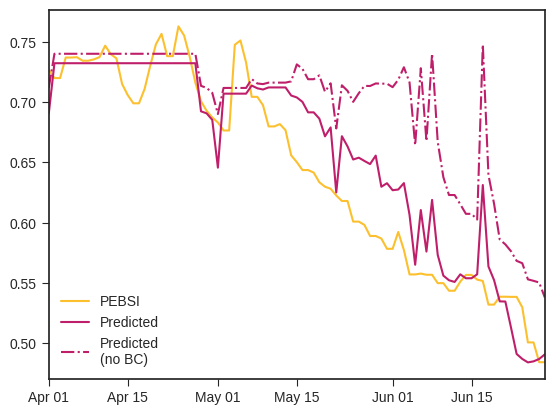

In [31]:
start, end = pd.to_datetime('2019-04-01'),pd.to_datetime('2019-06-28')
df = pd.read_csv(base_fp + 'all_snow_df_processed.csv')
df = df.loc[df['glaciersite'] == 'gulkanaB']
df.index = pd.to_datetime(df['time'])
df = df.loc[pd.date_range(start, end)]
fig, ax = plt.subplots()
ax.plot(df.index, df['albedo'], color=colors[1], label='PEBSI')
ax.plot(df.index, df['albedo_ml'], color=colors[4], label='Predicted')
ax.plot(df.index, df['albedo_ml_noBC'], color=colors[4], linestyle='-.', label='Predicted\n(no BC)')
ax.legend()
ax.tick_params(length=5)
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%b %d'))
ax.set_xlim(start, end)
plt.show()

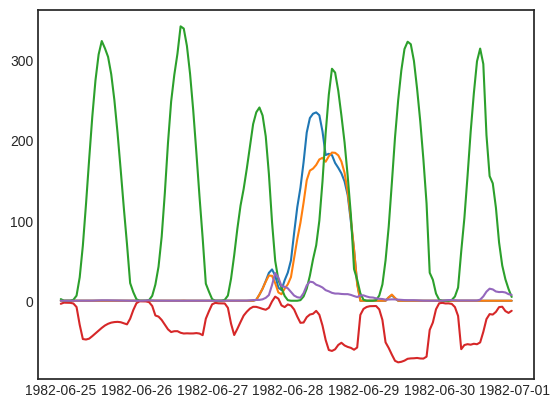

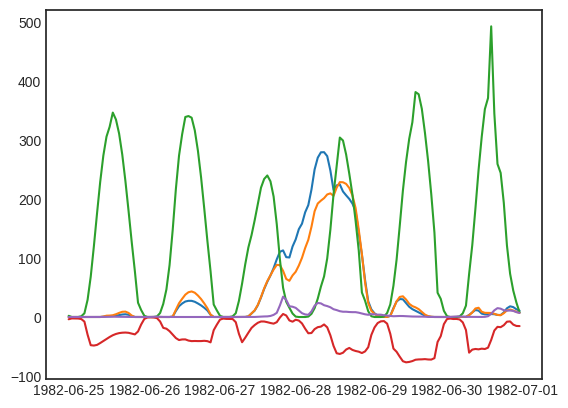

In [3]:
ds = xr.open_dataset(base_fp + 'kahiltnaK53_2026_03_19_long_0.nc')
ds = ds.sel(time=slice('1982-06-25', '1982-06-30'))
plt.plot(ds.time, ds.latent)
plt.plot(ds.time, ds.sensible)
plt.plot(ds.time, ds.SWnet)
plt.plot(ds.time, ds.LWnet)
plt.plot(ds.time, ds.rain)
plt.show()

ds = xr.open_dataset(base_fp + 'kahiltnaK53_2026_04_06_long_0.nc')
ds = ds.sel(time=slice('1982-06-25', '1982-06-30'))
plt.plot(ds.time, ds.latent)
plt.plot(ds.time, ds.sensible)
plt.plot(ds.time, ds.SWnet)
plt.plot(ds.time, ds.LWnet)
plt.plot(ds.time, ds.rain)
plt.show()

In [ ]:

# df = pd.read_csv(base_fp + 'glac_df_processed.csv')
# df.index = pd.to_datetime(df['time'])

# for glacier in site_dict:
#     for site in site_dict[glacier]:
#         da = df.loc[df['glaciersite'] == glacier+site]['albedo_ml'].to_xarray()
#         ds = da.to_dataset(name='albedo')
#         albedo = Albedo(glacier, site, use='all')
#         albedo.get_model_albedo(ds)
#         albedo.plot_1to1()

In [ ]:
glacier = 'gulkana'
site = 'B'
snowmelt_class = SnowMelt(glacier, site)
dem_class = DEM(glacier)
albedo = Albedo(glacier, site)
dem_class.reproject_to(albedo.ds)
albedo.plot_map_snowline('2021-07-01', snowmelt_class, dem_class, snowline_var='snowline_elev_m', plot_sites=[site])

In [ ]:
# FORCE THE MODEL USING REMOTELY SENSED ALBEDO
# for glacier in site_dict:
#     for site in site_dict[glacier]:
#         albedo = Albedo(glacier, site)
#         if len(np.where(~np.isnan(albedo.data))[0]) < 10:
#             continue

#         df_all = None
#         for year in np.unique(pd.to_datetime(albedo.time).year):
#             idx_year = np.where(pd.to_datetime(albedo.time).year == year)[0]
#             df = pd.DataFrame({'albedo': albedo.data.flatten()[idx_year]}, 
#                           index=pd.to_datetime(albedo.time)[idx_year])
#             df.index = pd.to_datetime(df.index).normalize()
#             df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='D'))
#             df = df.interpolate(method='time')

#             df.index = pd.DatetimeIndex(df.index)
            
#             df.loc[df.index.min() - pd.Timedelta(days=1),'albedo'] = 0.85
#             df.loc[df.index.max() + pd.Timedelta(days=1),'albedo'] = 0.85
#             df = df.sort_index()

#             if df_all is None:
#                 df_all = df 
#             else:
#                 df_all = pd.concat([df_all, df])

#         df_all = df_all.reindex(pd.date_range(df_all.index[0], df_all.index[-1]))
#         df_all = df_all.interpolate(method='time')
#         df_hourly = df.resample('h').ffill().sort_index()
#         plt.plot(df_all.index, df_all['albedo'])
#         # print(df_all)
#         df_all.to_csv(home_fp + f'climate_data/AWS/albedo/{glacier}{site}_S2albedo.csv')
#         # assert 1==0

In [ ]:
def find_kp(k, ds, bmeas, starts, ends):
    acc_mod = []
    add_mod = []
    for start, end in zip(starts, ends):
        acc_mod.append(ds.sel(time=slice(start, end)).accum.sum().values)
        refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
        melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
        add_mod.append(refreeze + melt)
    acc_mod = np.array(acc_mod)
    add_mod = np.array(add_mod)
    
    objective = np.mean(np.abs((acc_mod * k + add_mod) - np.array(bmeas)))
    return objective

all_albedo = {'mod':[], 'meas':[]}
for glacier in site_dict:
    site_fn = f'../data/by_glacier/{glacier}/site_constants.csv'
    site_df = pd.read_csv(site_fn, index_col=0)
    if 'kp' not in site_df.columns:
        site_df['kp'] = site_df['lat'].copy() * np.nan

    for site in site_dict[glacier]:
        mb = MassBalance(glacier, site, use='benchmark')
        ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_02_26_base_0.nc')

        # mb.get_model_mb(ds)
        # mb.plot_mb()
        # albedo = Albedo(glacier, site)
        # albedo.get_model_albedo(ds)
        # albedo.plot_timeseries()
        # for mod, meas in zip(albedo.mod, albedo.meas):
        #     all_albedo['mod'].append(mod)
        #     all_albedo['meas'].append(meas)

        if mb.dataset == 'seasonal':
            mb.get_model_mb(ds)
            starts = mb.period_starts[mb.idx_winter]
            ends = mb.period_ends[mb.idx_winter]
            bw_meas = mb.meas[mb.idx_winter]
            
            result = minimize(find_kp,1,
                                      method='L-BFGS-B',bounds=((0, 5),),
                                      args=(ds, bw_meas, starts, ends))
            kp = result.x[0]
            site_df.loc[site, 'kp'] = kp

            bw_mod = []
            bw_mod_kp = []
            for start, end in zip(starts, ends):
                acc = ds.sel(time=slice(start, end)).accum.sum().values
                refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
                melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
                bw_mod.append(acc + refreeze + melt)
                bw_mod_kp.append(acc*kp + refreeze + melt)

            print(glacier, site, kp)
            # plt.figure(figsize=(3,3))
            # plt.plot(pd.to_datetime(ends).year, bw_meas, 'k', label='Measured')
            # plt.plot(pd.to_datetime(ends).year, bw_mod, 'k--', label='Modeled')
            # plt.plot(pd.to_datetime(ends).year, bw_mod_kp, 'r', label=f'Model with kp {kp:.3f}')
            # plt.title(glacier+' '+site)
            # plt.legend()
            # plt.show()
    # site_df.to_csv(site_fn)

kahiltna K17b 0.7023414238186757
kahiltna K53 1.7068888637879764
kennicott GTH 1.6634793010179634
kennicott KC31 1.130154191842188
kennicott GTL 1.0094549347163355
gulkana AU 2.0588026401017103
gulkana B 2.710018518732716
gulkana D 3.1900623202381246
wolverine N 0.9877200957743191
wolverine B 1.1477651719827946
wolverine EC 1.981469475081177
lemon_creek B 1.4230809067903878
lemon_creek C 1.5168359512504206
lemon_creek D 1.5903339881579404


In [37]:
all_df = None
for glacier in site_dict:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']

    dsu = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
    dsv = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
    wind = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    dsv.values = wind 
    all_wind = dsv.resample(time='d').mean()
    # glac_qms = {'taku':'lemon_creek','kennicott':'gulkana'}
    # glac_qm = glac_qms[glacier] if glacier in glac_qms else glacier
    # df_qm = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_{glac_qm}_wind.csv')
    # adj = np.interp(values, df_qm['sorted'], df_qm['mapping'])
    # dsv.values = adj 
    # wind = dsv.resample(time='d').mean()

    for site in site_dict[glacier]:
        # albedo = Albedo(glacier, site)
        ds = xr.open_dataset(base_fp + f'../03_11_{glacier}_{site}_0/grid_03_11_set4_run0_0.nc') # '+glacier + site +'_2026_03_05_base_1.nc')
        # albedo.get_model_albedo(ds)
        # albedo.plot_timeseries()
        out = base_fp+f'{glacier}{site}_df.csv'
        df = get_ddf_df(ds, ds_bc,  n_rolling_bc=5, n_rolling_pdds=1, savefig=True) # output_fn=out, plot_corr=True,
        df['glacier'] = [glacier] * len(df.index)
        df['glaciersite'] = [glacier + site] * len(df.index)
        df['wind'] = all_wind.sel(time=pd.to_datetime(df.index)).values 
        if all_df is not None:
            all_df = pd.concat([all_df, df])
        else:
            all_df = df

/trace/home/cvwilson/miniconda3/envs/eb_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1598: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [38]:
acc_sites = []
for glacier in site_dict:
    for site in site_dict[glacier]:
        data = MassBalance(glacier, site, use='benchmark annual')
        if np.mean(data.data) > 0:
            acc_sites.append(glacier+site)

                      ddf       doy  pdds_1d_rolling      wind    albedo  \
ddf              1.000000 -0.132040        -0.430867  0.230437  0.023331   
doy             -0.132040  1.000000        -0.092740  0.246461 -0.621758   
pdds_1d_rolling -0.430867 -0.092740         1.000000 -0.329220 -0.179390   
wind             0.230437  0.246461        -0.329220  1.000000 -0.103084   
albedo           0.023331 -0.621758        -0.179390 -0.103084  1.000000   
bc_dep_cumsum   -0.024975  0.449152         0.012187  0.179773 -0.552631   
bc_5d_rolling    0.007436  0.042171         0.002400  0.055001 -0.209684   

                 bc_dep_cumsum  bc_5d_rolling  
ddf                  -0.024975       0.007436  
doy                   0.449152       0.042171  
pdds_1d_rolling       0.012187       0.002400  
wind                  0.179773       0.055001  
albedo               -0.552631      -0.209684  
bc_dep_cumsum         1.000000       0.123293  
bc_5d_rolling         0.123293       1.000000  


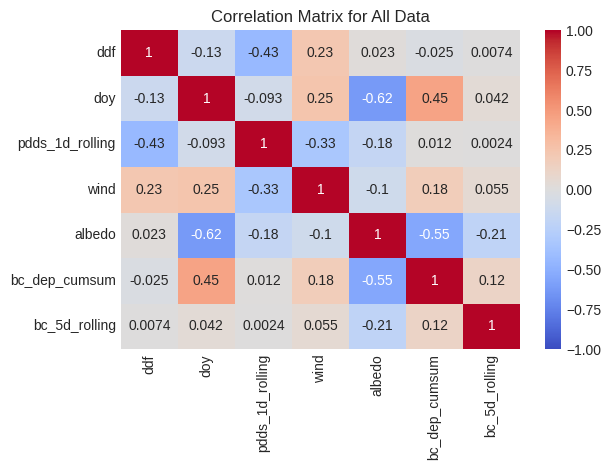

In [39]:
all_df = all_df.loc[all_df['glaciersite'].isin(acc_sites)]
all_df['doy'] = pd.to_datetime(all_df.index).day_of_year
corr = all_df[['ddf','doy','pdds_1d_rolling','wind','albedo','bc_dep_cumsum','bc_5d_rolling']].corr() # .drop(columns=['glacier','glaciersite'])
print(corr)
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'Correlation Matrix for All Data')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1912706/4103023244.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


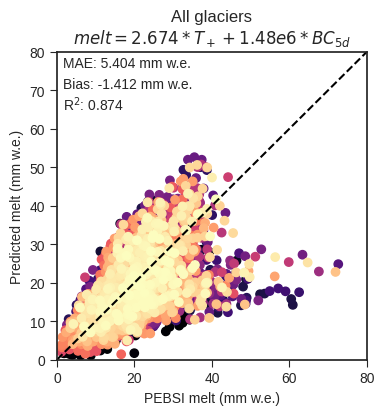

/tmp/ipykernel_1912706/4103023244.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


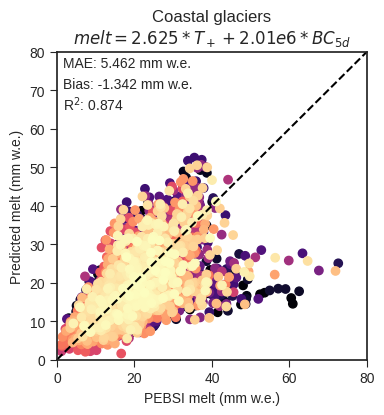

/tmp/ipykernel_1912706/4103023244.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


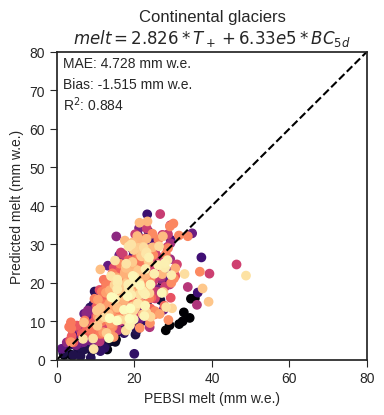

In [49]:
all_groups = {
          'all':['gulkana','wolverine','taku','kennicott','kahiltna','lemon_creek'], 
          'coastal':['wolverine','taku','lemon_creek'],
          'continental':['gulkana','kennicott','kahiltna'],
          }
for group in all_groups:
    glac_df = all_df.loc[all_df['glacier'].isin(all_groups[group])]
    X = glac_df[['pdds_1d_rolling' , 'bc_5d_rolling']] # 
    y = glac_df['melt']

    model = sm.OLS(y, X).fit()
    model.summary()

    ddf = model.params['pdds_1d_rolling']
    bcf = model.params['bc_5d_rolling']
    melt_predicted = glac_df['pdds_1d_rolling'] * ddf + glac_df['bc_5d_rolling'] * bcf 
    melt_actual = glac_df['melt']

    x = melt_actual.values
    y = melt_predicted.values
    xy = np.vstack([x, y])
    z = kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(melt_actual, melt_predicted, c=z, cmap='magma')
    ax.plot([0,80],[0,80],'k--')
    ax.legend()
    ax.tick_params(length=5)
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 80)
    ax.set_xlabel('PEBSI melt (mm w.e.)')
    ax.set_ylabel('Predicted melt (mm w.e.)')
    ax.set_title(f'{group.capitalize()} glaciers\n$melt={ddf:.3f}*T_+'+f'+{bcf:.2e}*'.replace('e+0','e')+r'BC_{5d}$')

    mae = np.nanmean(np.abs(melt_predicted - melt_actual))
    bias = np.nanmean(melt_predicted - melt_actual)
    r2 = model.rsquared
    ax.text(0.02, 0.95, f'MAE: {mae:.3f} mm w.e.', transform=ax.transAxes)
    ax.text(0.02, 0.88, f'Bias: {bias:.3f} mm w.e.', transform=ax.transAxes)
    ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

    plt.show()

/tmp/ipykernel_1912706/1688820569.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


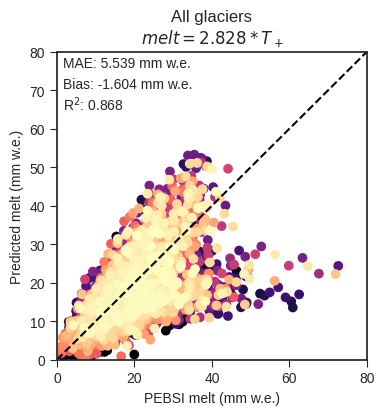

/tmp/ipykernel_1912706/1688820569.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


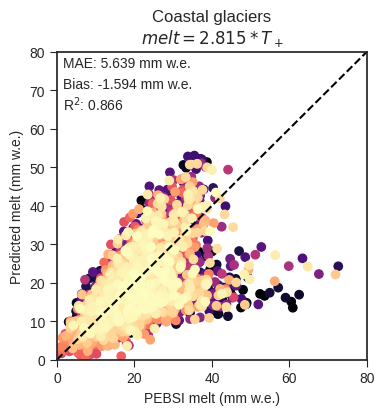

/tmp/ipykernel_1912706/1688820569.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


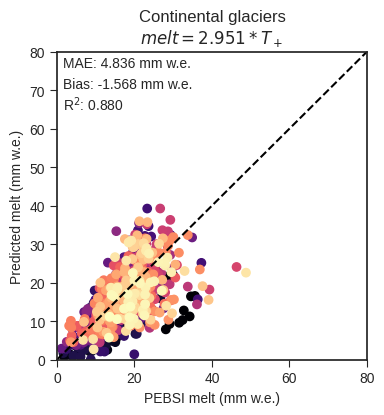

In [44]:
all_groups = {
          'all':['gulkana','wolverine','taku','kennicott','kahiltna','lemon_creek'], 
          'coastal':['wolverine','taku','lemon_creek'],
          'continental':['gulkana','kennicott','kahiltna'],
          }
for group in all_groups:
    glac_df = all_df.loc[all_df['glacier'].isin(all_groups[group])]
    X = glac_df[['pdds_1d_rolling']] # , 'bc_5d_rolling']] # 
    y = glac_df['melt']

    model = sm.OLS(y, X).fit()
    model.summary()

    ddf = model.params['pdds_1d_rolling']
    # bcf = model.params['bc_5d_rolling']
    melt_predicted = glac_df['pdds_1d_rolling'] * ddf # + glac_df['bc_5d_rolling'] * bcf 
    melt_actual = glac_df['melt']

    x = melt_actual.values
    y = melt_predicted.values
    xy = np.vstack([x, y])
    z = kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(melt_actual, melt_predicted, c=z, cmap='magma')
    ax.plot([0,80],[0,80],'k--')
    ax.legend()
    ax.tick_params(length=5)
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 80)
    ax.set_xlabel('PEBSI melt (mm w.e.)')
    ax.set_ylabel('Predicted melt (mm w.e.)')
    ax.set_title(f'{group.capitalize()} glaciers\n$melt={ddf:.3f}*T_+$') #+{bcf:.2e}*'.replace('e+0','e')+r'BC_{5d}$')

    mae = np.nanmean(np.abs(melt_predicted - melt_actual))
    bias = np.nanmean(melt_predicted - melt_actual)
    r2 = model.rsquared
    ax.text(0.02, 0.95, f'MAE: {mae:.3f} mm w.e.', transform=ax.transAxes)
    ax.text(0.02, 0.88, f'Bias: {bias:.3f} mm w.e.', transform=ax.transAxes)
    ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

    plt.show()


In [42]:
X = all_df[['pdds_1d_rolling', 'bc_5d_rolling']] # 
y = all_df['melt']

model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   melt   R-squared (uncentered):                   0.874
Model:                            OLS   Adj. R-squared (uncentered):              0.874
Method:                 Least Squares   F-statistic:                          2.209e+04
Date:                Wed, 18 Mar 2026   Prob (F-statistic):                        0.00
Time:                        11:08:05   Log-Likelihood:                         -21786.
No. Observations:                6384   AIC:                                  4.358e+04
Df Residuals:                    6382   BIC:                                  4.359e+04
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [11]:
print(all_df.loc[all_df['melt'] > 60])

                 ddf  days_since_accum  accum_cumsum  accum_3d_rolling  \
time                                                                     
2022-07-08  3.391932              18.0   3698.937864               0.0   
2015-08-18  3.012809              67.0   2791.193469               0.0   
2021-08-13  5.538480              55.0   3495.032970               0.0   
2015-08-18  3.116969              66.0   3034.030394               0.0   

            pdds_cumsum  pdds_1d_rolling       melt    snow_BC       rain  \
time                                                                        
2022-07-08   269.032871         5.993833  60.089004  23.905781  70.115976   
2015-08-18   856.369680         8.612833  70.700316  76.917199  73.432487   
2021-08-13   641.213835         9.346167  61.580826  64.005941  85.703483   
2015-08-18   763.808680         7.897833  65.866058  72.356423  76.990646   

              albedo  bc_dep_cumsum  bc_5d_rolling      glacier   glaciersite  \
time       

In [ ]:
cats = all_df['glaciersite'].astype('category').cat.categories
codes = all_df['glaciersite'].astype('category').cat.codes

# pick a colormap with enough distinct colors
base_cmap = plt.cm.get_cmap('Dark2', len(cats))
cmap = mpl.colors.ListedColormap(base_cmap.colors)

plt.scatter(
    all_df['pdds_3d_rolling'],
    all_df['ddf'],
    c=codes,
    cmap=cmap
)

# legend
for code, name in enumerate(cats):
    plt.scatter([], [], color=cmap(code), label=name)

plt.legend(title='Glacier')
plt.show()


In [ ]:
glacier = 'gulkana'
site = 'B'
data = SnowMelt(glacier, site)
ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_02_03_base_long_0.nc')
data.get_model_snow(ds)
error = data.model_error_metric(data.mod_melt, data.sar_melt['med'], data.time, transition_type='onset')
print('Melt onset MAE:',error,'days')

error = data.model_error_metric(data.mod_snow, data.sar_snow['med'], data.time, transition_type='offset')
print('Snowline MAE:',error,'days')

In [ ]:
data.plot_snow_bool()
data.plot_melt_bool()

In [ ]:
#comparing quantile mapping approaches
# ds_lemon = xr.open_dataset(base_fp + 'takuTKG3_2026_02_15_base_qmlemonkp2_0.nc')
# ds_gulk = xr.open_dataset(base_fp + 'takuTKG3_2026_02_12_base_qmallkp2_0.nc')

coords = '58.5_-134.3'
for var in ['wind','temp','rh']:
    if var == 'wind':
        dsu = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
        dsv = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
        ds_clim = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    elif var == 'rh':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/RH2M_{coords}.nc')['RH2M'].values
    elif var == 'temp':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/T2M_{coords}.nc')['T2M'].values - 273.15
    varn = var if var != 'temp' else 'temp_0'
    df_gulk = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_gulkana_{varn}.csv')
    df_lem = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_lemon_creek_{varn}.csv')
        
    # interpolate values according to quantile mapping
    values = ds_clim
    adj_gulk = np.interp(values, df_gulk['sorted'], df_gulk['mapping'])
    adj_lem = np.interp(values, df_lem['sorted'], df_lem['mapping'])

    # plt.scatter(adj_gulk, adj_lem, s=5, alpha=0.5)
    plt.scatter(values, adj_lem, s=5, alpha=0.5,label='lemon')
    plt.scatter(values, adj_gulk, s=5, alpha=0.5,label='gulkana')
    minn = np.min([adj_gulk, adj_lem])
    maxx = np.max([adj_gulk, adj_lem])
    plt.ylabel('Original MERRA-2') # Lemon Creek adjusted')
    plt.xlabel('Adjusted') # Gulkana adjusted')
    plt.plot([minn,maxx],[minn,maxx],'k--')
    plt.legend()
    plt.title(var)
    plt.show()

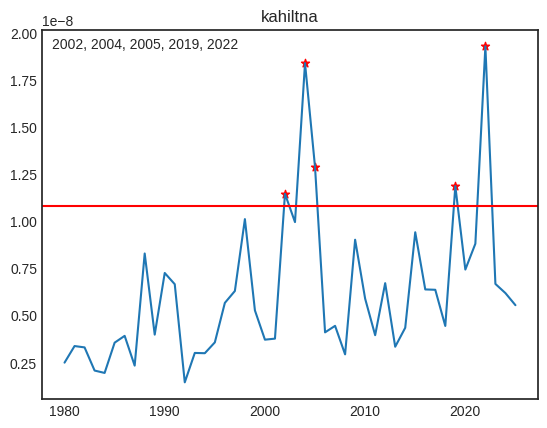

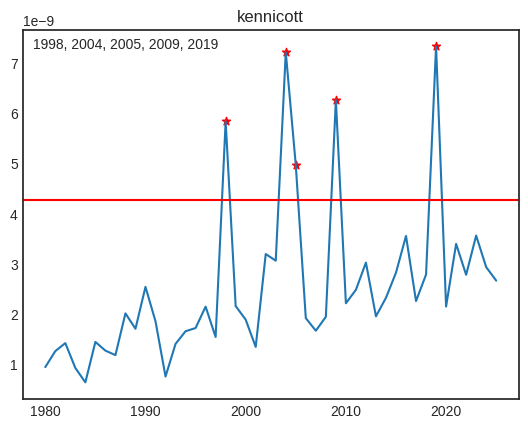

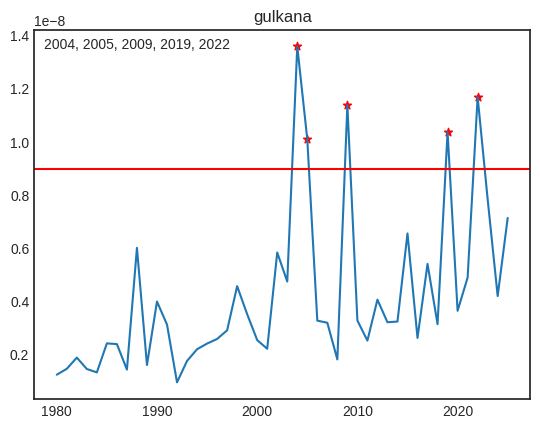

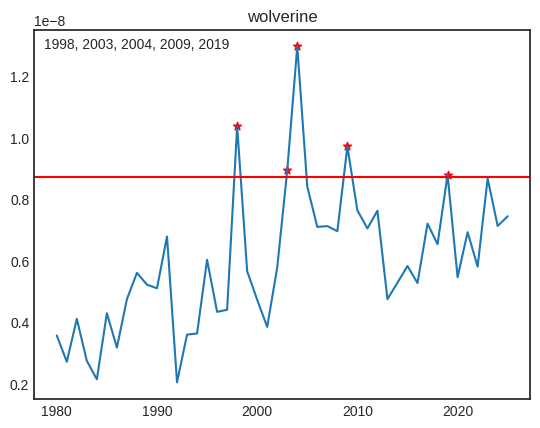

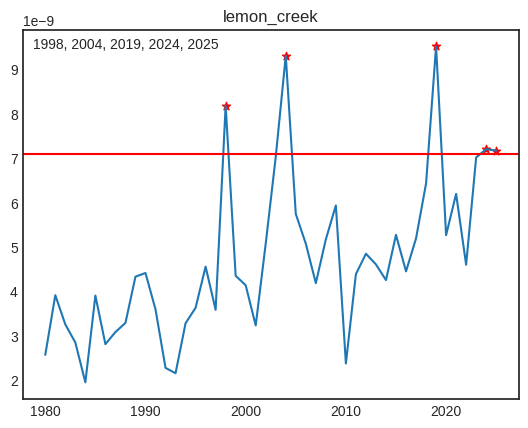

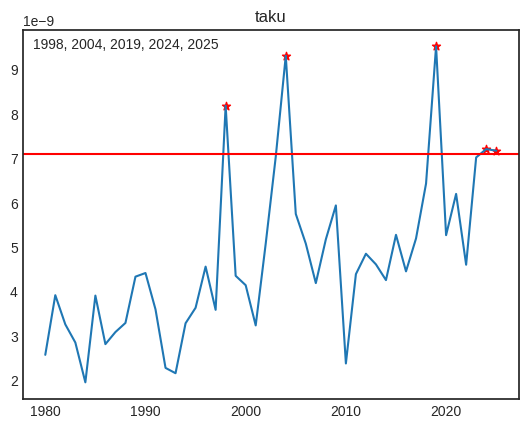

In [61]:
for glacier in site_dict:
    coords = coord_dict[glacier]
    ds = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds2 = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds['BCDP002'] = ds['BCDP002'] + ds2['BCWT002']
    # define time variables
    months = ds['time'].dt.month
    days = ds['time'].dt.day
    # create time mask from apr 1 to sep 30 (inclusive)
    mask = ((months > 3) & (months < 10))
    ds_season = ds.where(mask, drop=True)
    annual_sums = ds_season.groupby('time.year').sum()
    fig, ax = plt.subplots()
    ax.plot(annual_sums.year, annual_sums['BCDP002'].values)
    ax.axhline(np.quantile(annual_sums['BCDP002'].values, 0.90), c='r')

    threshold = np.quantile(annual_sums['BCDP002'].values, 0.90)
    base_idx = np.where(annual_sums['BCDP002'].values <= threshold)[0]
    fire_idx = np.where(annual_sums['BCDP002'].values > threshold)[0]

    fire_years = annual_sums.year.values[fire_idx]
    base_years = annual_sums.year.values[base_idx]

    ax.set_title(glacier)
    ax.scatter(annual_sums.year.values[fire_idx], annual_sums['BCDP002'].values[fire_idx], color='red', marker='*')
    ax.text(0.02, 0.95, ', '.join(fire_years.astype(str)), transform=ax.transAxes)
    plt.show()